In [1]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, numpy as np
import torch
import os

In [2]:
from matplotlib import font_manager

font_dirs = ['/home/shenm19/arial-font/']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

# set font
plt.rcParams['font.family'] = 'Arial'

In [3]:
df1 = pd.read_csv('experiment_metrics_fully_parallel/default3.csv')
df2 = pd.read_csv('experiment_metrics_fully_parallel/train-0.01.csv')
df3 = pd.read_csv('experiment_metrics_fully_parallel/train-0.001.csv')

# Use index instead of step
for df in [df1, df2, df3]:
    df['index'] = df.index

In [4]:
df2.columns

Index(['equiv/t=0.2/total_mse', 'train/auxiliary_loss_step',
       'equiv/t=0/mean_pred_error', 'equiv/t=0.9/mean_pred_error',
       'train/trans_loss_step', 'validation_loss/auxiliary_loss_epoch',
       'validation_loss/trans_loss_epoch', 'equiv/t=0.4/total_mse',
       'equiv/t=0.8/mean_pred_error', 'equiv/t=0.9/equiv_grad_norm',
       'train/dist_mat_loss_epoch', 'equiv/t=0.2/mean_grad_norm',
       'train/loss_step', 'validation_loss/distogram_loss_epoch',
       'train/auxiliary_loss_epoch', 'validation_loss/dist_mat_loss_epoch',
       'equiv/t=0.4/pct_loss_from_equiv_error', 'equiv/t=0.95/mean_grad_norm',
       'equiv/t=0.99/mean_grad_norm', 'equiv/t=0/pct_loss_from_equiv_error',
       'scaling/nparams', 'equiv/t=0.6/equiv_grad_norm',
       'equiv/t=0.8/total_mse', 'equiv/t=0/equiv_error', 'trainer/global_step',
       'equiv/t=0.99/total_mse', 'equiv/t=0.99/equiv_grad_norm',
       'equiv/t=0.2/pct_loss_from_equiv_error', 'train_loss_step',
       'equiv/t=0.6/mean_grad_

In [5]:
def variable_span_ema(data: pd.Series, span_scale_factor: int = 1000) -> pd.Series:
    """
    Calculates an EMA with a span that increases with the index value (timestep).

    Args:
        data (pd.Series): The input data to smooth. Must have a numeric index (e.g., timesteps).
        span_scale_factor (int): Controls how quickly the span grows. A larger value
                                 means the span grows slower, resulting in less smoothing.
                                 The span at a given timestep `x` is roughly `x / span_scale_factor`.

    Returns:
        pd.Series: The smoothed data with the same index as the input.
    """
    if data.empty:
        return data

    # Get index and values for faster iteration
    index = data.index.to_numpy()
    values = data.to_numpy()
    
    # Initialize the output array and the first EMA value
    ema_values = np.zeros_like(values)
    ema_values[0] = values[0] 

    # Iterate from the second point onwards
    for i in range(1, len(values)):
        current_step = index[i]
        
        # 1. Calculate the variable span. Ensure it's at least 1.
        span = max(1.0, current_step / span_scale_factor)
        
        # 2. Convert span to alpha
        alpha = 2.0 / (span + 1.0)
        
        # 3. Apply the EMA formula
        ema_values[i] = alpha * values[i] + (1 - alpha) * ema_values[i-1]
        
    return pd.Series(ema_values, index=data.index)


### 0.01

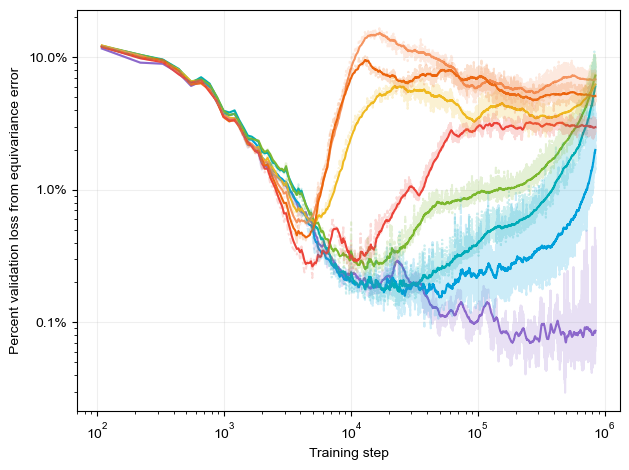

In [14]:
color_palette = {
    't=0': '#8c68cb',
    't=0.2': '#00a0dc',
    't=0.4': '#00aeb3',
    't=0.6': '#7cb82f',
    't=0.8': '#efb920',
    't=0.9': '#f59460',
    't=0.95': '#ec640c',
    't=0.99': '#ec4339',
}

chosen_df = df2

cols = ['index'] + [col for col in chosen_df.columns if col.startswith('equiv/t=') and col.endswith('pct_loss_from_equiv_error')]

plot_df = chosen_df[cols].dropna().reset_index(drop=True).set_index('index')
plot_df = plot_df.rename(columns=lambda x: x.replace('equiv/t=', 't=').replace('/pct_loss_from_equiv_error', ''))
plot_df = plot_df[sorted(plot_df.columns)]

smoothed_plot_df = plot_df.apply(variable_span_ema)
melted_smoothed_plot_df = pd.melt(smoothed_plot_df.reset_index(), id_vars=['index'], var_name = 'time', value_name = 'pct_loss_from_equiv_error')

fig, ax = plt.subplots()
sns.lineplot(
    data = melted_smoothed_plot_df,
    x = 'index',
    y = 'pct_loss_from_equiv_error',
    hue = 'time',
    errorbar = None,
    palette=color_palette,
    linestyle='-',
    alpha=1.0,
    legend = False,
    ax=ax,
)
sns.lineplot(
    data = plot_df,
    errorbar = None,
    palette=color_palette,
    alpha=0.2,
    legend=False,
    ax=ax,
)

plt.yscale('log')
plt.xscale('log')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha = 0.2)

plt.xlabel(f'Training step');
plt.ylabel(f'Percent validation loss from equivariance error');

import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# plt.savefig('prot_60M_0.01.png', bbox_inches='tight', dpi=300)
# plt.show()
# plt.close()

plot_name = f"prot_60M_0.01"

import os
os.makedirs('pdfs', exist_ok=True)

plt.tight_layout()
plt.savefig(plot_name + '.png', dpi=300, bbox_inches='tight')
plt.savefig('pdfs/' + plot_name + '.pdf', transparent = True)
plt.show()
plt.close()

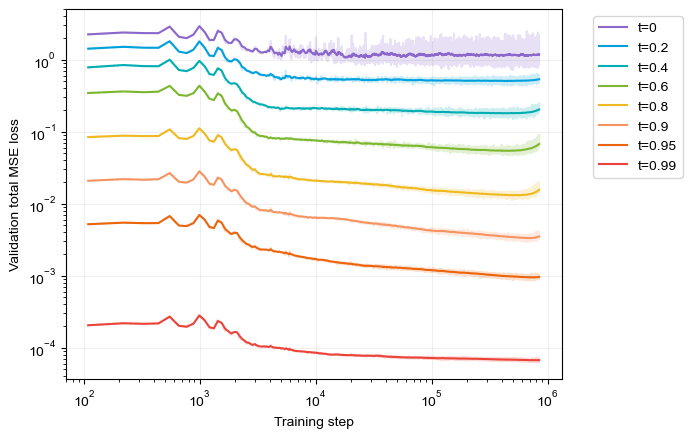

In [15]:
color_palette = {
    't=0': '#8c68cb',
    't=0.2': '#00a0dc',
    't=0.4': '#00aeb3',
    't=0.6': '#7cb82f',
    't=0.8': '#efb920',
    't=0.9': '#f59460',
    't=0.95': '#ec640c',
    't=0.99': '#ec4339',
}

chosen_df = df2

cols = ['index'] + [col for col in chosen_df.columns if col.startswith('equiv/t=') and col.endswith('total_mse')]

plot_df = chosen_df[cols].dropna().reset_index(drop=True).set_index('index')
plot_df = plot_df.rename(columns=lambda x: x.replace('equiv/t=', 't=').replace('/total_mse', ''))
plot_df = plot_df[sorted(plot_df.columns)]

smoothed_plot_df = plot_df.apply(variable_span_ema)
melted_smoothed_plot_df = pd.melt(smoothed_plot_df.reset_index(), id_vars=['index'], var_name = 'time', value_name = 'total_mse')

sns.lineplot(
    data = melted_smoothed_plot_df,
    x = 'index',
    y = 'total_mse',
    hue = 'time',
    errorbar = None,
    palette=color_palette,
    linestyle='-',
    alpha=1.0,
)
sns.lineplot(
    data = plot_df,
    errorbar = None,
    palette=color_palette,
    alpha=0.2,
    legend=False,
)

plt.yscale('log')
plt.xscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha = 0.2)

plt.xlabel(f'Training step');
plt.ylabel(f'Validation total MSE loss');

# plt.savefig('prot_60M_0.01.png', bbox_inches='tight', dpi=300)
plt.show()
plt.close()



### 0.001

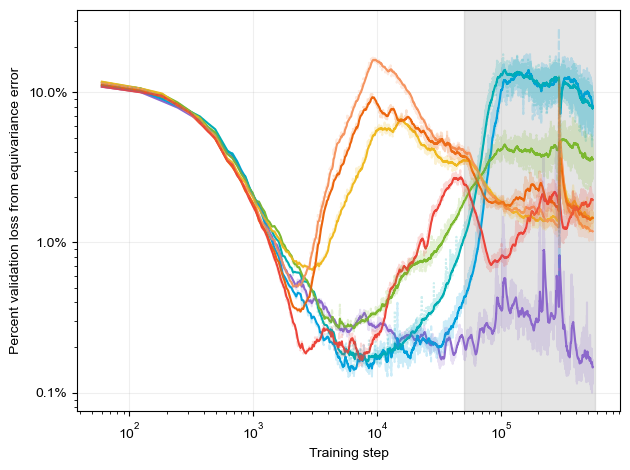

In [16]:
color_palette = {
    't=0': '#8c68cb',
    't=0.2': '#00a0dc',
    't=0.4': '#00aeb3',
    't=0.6': '#7cb82f',
    't=0.8': '#efb920',
    't=0.9': '#f59460',
    't=0.95': '#ec640c',
    't=0.99': '#ec4339',
}

chosen_df = df3

cols = ['index'] + [col for col in chosen_df.columns if col.startswith('equiv/t=') and col.endswith('pct_loss_from_equiv_error')]

plot_df = chosen_df[cols].dropna().reset_index(drop=True).set_index('index')
plot_df = plot_df.rename(columns=lambda x: x.replace('equiv/t=', 't=').replace('/pct_loss_from_equiv_error', ''))
plot_df = plot_df[sorted(plot_df.columns)]

smoothed_plot_df = plot_df.apply(variable_span_ema)
melted_smoothed_plot_df = pd.melt(smoothed_plot_df.reset_index(), id_vars=['index'], var_name = 'time', value_name = 'pct_loss_from_equiv_error')

fig, ax = plt.subplots()
sns.lineplot(
    data = melted_smoothed_plot_df,
    x = 'index',
    y = 'pct_loss_from_equiv_error',
    hue = 'time',
    errorbar = None,
    palette=color_palette,
    linestyle='-',
    alpha=1.0,
    legend = False,
    ax = ax,
)
sns.lineplot(
    data = plot_df,
    errorbar = None,
    palette=color_palette,
    alpha=0.2,
    legend=False,
    ax = ax,
)

left, right = plt.xlim()
ax.axvspan(50_000, right, color = 'gray', alpha = 0.2, label = 'Overfitted region')

plt.yscale('log')
plt.xscale('log')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha = 0.2)

plt.xlabel(f'Training step');
plt.ylabel(f'Percent validation loss from equivariance error');

import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# plt.savefig('prot_60M_0.001.png', bbox_inches='tight', dpi=300)
# plt.show()
# plt.close()

plot_name = f"prot_60M_0.001"

import os
os.makedirs('pdfs', exist_ok=True)

plt.tight_layout()
plt.savefig(plot_name + '.png', dpi=300, bbox_inches='tight')
plt.savefig('pdfs/' + plot_name + '.pdf', transparent = True)
plt.show()
plt.close()

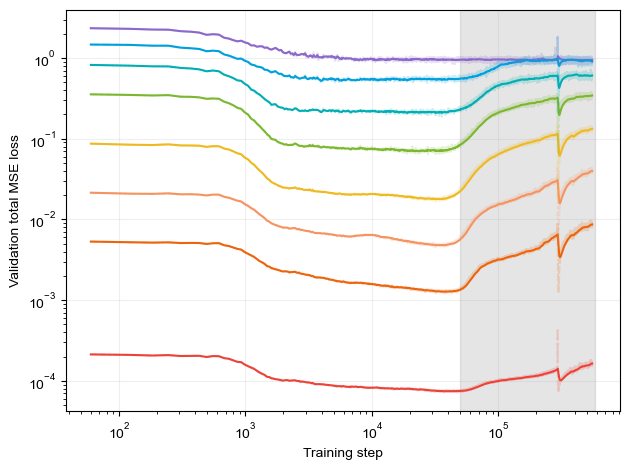

In [17]:
color_palette = {
    't=0': '#8c68cb',
    't=0.2': '#00a0dc',
    't=0.4': '#00aeb3',
    't=0.6': '#7cb82f',
    't=0.8': '#efb920',
    't=0.9': '#f59460',
    't=0.95': '#ec640c',
    't=0.99': '#ec4339',
}

chosen_df = df3

cols = ['index'] + [col for col in chosen_df.columns if col.startswith('equiv/t=') and col.endswith('total_mse')]

plot_df = chosen_df[cols].dropna().reset_index(drop=True).set_index('index')
plot_df = plot_df.rename(columns=lambda x: x.replace('equiv/t=', 't=').replace('/total_mse', ''))
plot_df = plot_df[sorted(plot_df.columns)]

smoothed_plot_df = plot_df.apply(variable_span_ema)
melted_smoothed_plot_df = pd.melt(smoothed_plot_df.reset_index(), id_vars=['index'], var_name = 'time', value_name = 'total_mse')

fig, ax = plt.subplots()
sns.lineplot(
    data = melted_smoothed_plot_df,
    x = 'index',
    y = 'total_mse',
    hue = 'time',
    errorbar = None,
    palette=color_palette,
    linestyle='-',
    alpha=1.0,
    legend = False,
    ax = ax,
)
sns.lineplot(
    data = plot_df,
    errorbar = None,
    palette=color_palette,
    alpha=0.2,
    legend=False,
    ax = ax,
)

left, right = plt.xlim()
ax.axvspan(50_000, right, color = 'gray', alpha = 0.2, label = 'Overfitted region')


plt.yscale('log')
plt.xscale('log')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha = 0.2)

plt.xlabel(f'Training step');
plt.ylabel(f'Validation total MSE loss');

# plt.savefig('prot_60M_0.001-total-mse.png', bbox_inches='tight', dpi=300)
# plt.show()
# plt.close()

plot_name = f"prot_60M_0.001-total-mse"

import os
os.makedirs('pdfs', exist_ok=True)

plt.tight_layout()
plt.savefig(plot_name + '.png', dpi=300, bbox_inches='tight')
plt.savefig('pdfs/' + plot_name + '.pdf', transparent = True)
plt.show()
plt.close()